# Language analysis notebook

Description
Na razie faza beta: 
języki - EN, it, ESP

k = [3, 10, 100, 1000]

texts - Umberto Eco - Imie Rozy (IT), Ch. Dickens - Olivier Twist (EN), Miguel de Unamuno - Niebla (ESP)

## Imports and configs

In [58]:
from pathlib import Path

from wikiscraper.analysis.words import WordCounter
from wikiscraper.scraper.client import WikiClient
from wikiscraper.scraper.parser import ArticleParser

### path to counts
save_path = Path("store_counts/")

### config
mode = "rank"

## Defining different scoring options

In [59]:
def lang_confidence_score(word_counts, language_words_with_frequency, mode="coverage"):
    if mode == "coverage":
        top_k = set(language_words_with_frequency.keys())
        total = sum(word_counts.values())
        covered = sum(count for word, count in word_counts.items() if word in top_k)
        return covered / total
    elif mode=="weighted_coverage":
        top_k = language_words_with_frequency
        total = sum(word_counts.values())

        score = 0
        for word, count in word_counts.items():
            if word in top_k:
                score += count * top_k[word]

        return score / total
    elif mode=="rank":
        rank = {w: i+1 for i, w in enumerate(language_words_with_frequency.keys())}
        total = sum(word_counts.values())
        score = 0

        for word, count in word_counts.items():
            if word in rank:
                score += count * (1 / rank[word])

        return score / total

## Explorative loop to find worst wiki article

In [60]:
### Crawler to get texts
from wikiscraper.analysis.words import RelativeFrequencyAnalyzer
from wikiscraper.scraper.crawler import AutoCrawler

phrase = "Team_Rocket"  ### I will look at kids of Team Rocket
explorative_texts = {}
client = WikiClient()
html = client.fetch_html(phrase)
parser = ArticleParser(html)
links = parser.extract_links()

for link in links[:51]:
    html = client.fetch_html(link)
    parser = ArticleParser(html)
    text = parser.extract_article_text()
    save_phrase = save_path / f"{link}.json"
    counter = WordCounter(counts_path=save_phrase)
    tokens = counter.tokenize(text)
    if Path(save_phrase).exists():
        counter.reset_counts()
    current_dict = counter.run(text)
    explorative_texts[link] = current_dict




In [61]:
### Find those with the lowest english to it and es difference
texts = explorative_texts.keys()
languages = ["en", "es", "it"]
scores = {}
for text in texts:
    scores[text] = {}
    for ln in languages:
        freq_analyzer = RelativeFrequencyAnalyzer(
            top_k=1000,
            mode="language",
            lang=ln,
            lang_top_k=1000,
            counts=explorative_texts[text],
        )
        article_norm, lang_norm, selected_words = freq_analyzer.return_norms()
        scores[text][ln] = lang_confidence_score(explorative_texts[text],lang_norm, mode=mode)

In [ ]:
### pick text with lowest results for other languages
sum_dict = {
    text: (scores[text]["en"] - scores[text]["es"])
    + scores[text]["en"]
    - (scores[text]["it"])
    for text in scores.keys()
}
sorted(sum_dict.items(), key=lambda x: x[1])
### So the choice is "Five_Island"
chosen = sorted(sum_dict.items(), key=lambda x: x[1])[0][0]
chosen

'Sham'

## Loading data and processing to a dictionary

In [63]:
texts_dicts = {}

texts = ["english.txt", "italian.txt", "spanish.txt"]  ### teksty z literatury
phrases = [
    chosen,
    "Team Rocket",  ### dluzszy artykul
]

for phrase in phrases:
    client = WikiClient()
    html = client.fetch_html(phrase)
    parser = ArticleParser(html)
    text = parser.extract_article_text()
    rocket_text = text
    save_phrase = save_path / f"{phrase}.json"
    counter = WordCounter(counts_path=save_phrase)
    tokens = counter.tokenize(text)
    if Path(save_phrase).exists():
        counter.reset_counts()
    current_dict = counter.run(text)
    texts_dicts[phrase] = current_dict
    # links = parser.extract_links(prefix="/wiki/")
    # print(len(tokens))

for txt in texts:
    save_text = save_path / f"{txt}"
    with open(save_text, "r") as f:
        text = Path(save_text).read_text(encoding="utf-8")
        counter = WordCounter(counts_path=save_path / f"{txt[:-4]}.json")
        tokens = counter.tokenize(text)
        if Path(save_text).exists():
            counter.reset_counts()
        current_dict = counter.run(text)
        texts_dicts[txt[:-4]] = current_dict
        # print(len(tokens))

In [64]:
for name, wc in texts_dicts.items():
    print(name, "unique:", len(wc), "total:", sum(wc.values()))


Sham unique: 190 total: 391
Team Rocket unique: 1517 total: 6271
english unique: 1402 total: 5027
italian unique: 1974 total: 5307
spanish unique: 1705 total: 6094


### Final loop with selected articles to calculate scores

In [65]:
from wikiscraper.analysis.words import RelativeFrequencyAnalyzer

languages = ["en", "it", "es"]
freqs = {}
scores = {}
for k in [3, 10, 100, 500, 1000]:
    scores[str(k)] = {}
    for name, txt in texts_dicts.items():
        scores[str(k)][name] = {}
        for ln in languages:
            freq_analyzer = RelativeFrequencyAnalyzer(
                top_k=1000,
                mode="language",
                lang=ln,
                lang_top_k=k,
                counts=texts_dicts[name],
            )
            article_norm, lang_norm, selected_words = freq_analyzer.return_norms()
            scores[str(k)][name][ln] = lang_confidence_score(
                texts_dicts[name], lang_norm, mode=mode
            )

In [66]:
len(scores["3"])

5

In [67]:
from __future__ import annotations

from typing import Iterable, Optional

import matplotlib.pyplot as plt
import pandas as pd


def scores_dict_to_df(
    scores: dict,
    ks: Optional[Iterable[int]] = None,
    texts: Optional[Iterable[str]] = None,
    languages: Optional[Iterable[str]] = None,
) -> pd.DataFrame:

    # infer ks/texts/languages if not provided
    all_ks = sorted(scores.keys())
    if ks is None:
        ks = all_ks
    else:
        ks = sorted(ks)

    sample_k = next(iter(scores))
    all_texts = sorted(scores[sample_k].keys())
    if texts is None:
        texts = all_texts
    else:
        texts = list(texts)

    sample_text = next(iter(scores[sample_k]))
    all_langs = sorted(scores[sample_k][sample_text].keys())
    if languages is None:
        languages = all_langs
    else:
        languages = list(languages)

    rows = []
    for k in ks:
        for text in texts:
            for lang in languages:
                val = scores.get(k, {}).get(text, {}).get(lang, None)
                rows.append({"k": k, "text": text, "language": lang, "score": val})

    df = pd.DataFrame(rows)
    df["k"] = df["k"].astype(int)
    df["score"] = pd.to_numeric(df["score"], errors="coerce")
    return df


def plot_df_per_text(
    df: pd.DataFrame,
    ks: Optional[Iterable[int]] = None,
    texts: Optional[Iterable[str]] = None,
    languages: Optional[Iterable[str]] = None,
    title_prefix: str = "Language confidence",
    xscale_log: bool = True,
) -> None:
    if ks is not None:
        df = df[df["k"].isin(list(ks))]
    if texts is not None:
        df = df[df["text"].isin(list(texts))]
    if languages is not None:
        df = df[df["language"].isin(list(languages))]

    for text, sub in df.groupby("text", sort=True):
        plt.figure(figsize=(9, 4.8))
        for lang, sub2 in sub.groupby("language", sort=True):
            sub2 = sub2.sort_values("k")
            plt.plot(sub2["k"], sub2["score"], marker="o", label=lang)

        if xscale_log:
            plt.xscale("log")

        plt.title(f"{title_prefix} — text: {text}")
        plt.xlabel("k (top-k words)")
        plt.ylabel("score")
        plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
        plt.legend()
        plt.show()


def plot_df_per_language(
    df: pd.DataFrame,
    ks: Optional[Iterable[int]] = None,
    texts: Optional[Iterable[str]] = None,
    languages: Optional[Iterable[str]] = None,
    title_prefix: str = "Language confidence",
    xscale_log: bool = True,
) -> None:

    if ks is not None:
        df = df[df["k"].isin(list(ks))]
    if texts is not None:
        df = df[df["text"].isin(list(texts))]
    if languages is not None:
        df = df[df["language"].isin(list(languages))]

    for lang, sub in df.groupby("language", sort=True):
        plt.figure(figsize=(9, 4.8))
        for text, sub2 in sub.groupby("text", sort=True):
            sub2 = sub2.sort_values("k")
            plt.plot(sub2["k"], sub2["score"], marker="o", label=text)

        if xscale_log:
            plt.xscale("log")

        plt.title(f"{title_prefix} — language: {lang}")
        plt.xlabel("k (top-k words)")
        plt.ylabel("score")
        plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
        plt.legend()
        plt.show()

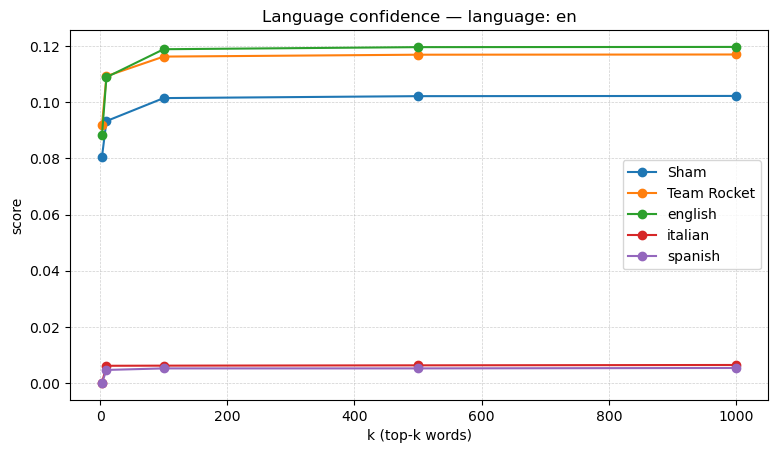

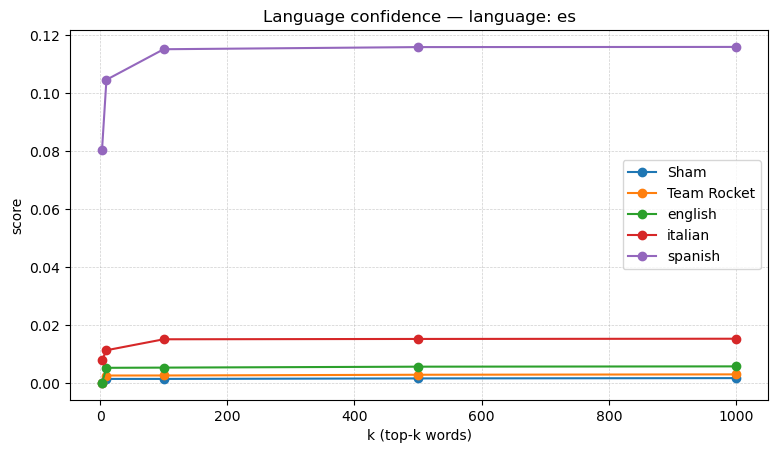

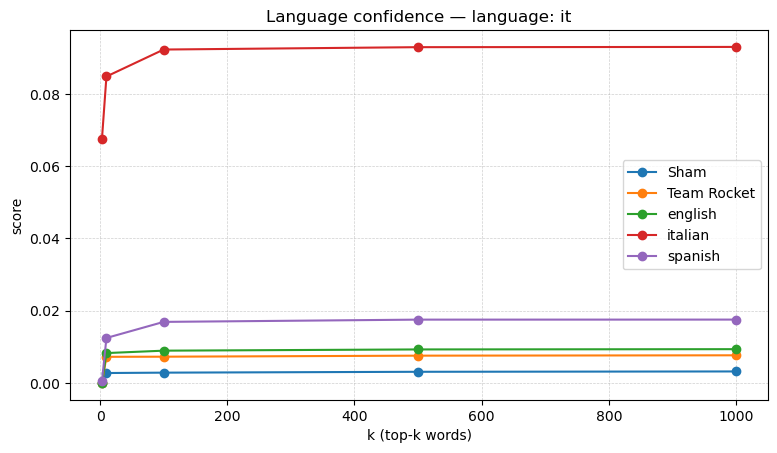

In [69]:
df = scores_dict_to_df(scores)
# plot_df_per_text(df, ks=[3, 10, 100,500, 1000], xscale_log=False)
plot_df_per_language(df, ks=[3, 10, 100,500, 1000], xscale_log=False)